In [77]:
import mne
import numpy
import pickle
import seaborn
import collections
import matplotlib.pyplot as plt

import SDA.topology

In [78]:
REGION_MAP = {
    'Fp1': 'FP',
    'Fpz': 'FP',
    'Fp2': 'FP',
    'F7': 'LF',
    'F3': 'LF',
    'Fz': 'MF',
    'F4': 'RF',
    'F8': 'RF',
    'FT7': 'LF',
    'FC3': 'LF',
    'FCz': 'MF',
    'FC4': 'RF',
    'FT8': 'RF',
    'T3': 'LT',
    'C3': 'LC',
    'Cz': 'MC',
    'C4': 'RC',
    'T4': 'RT',
    'TP7': 'LT',
    'CP3': 'LC',
    'CPz': 'MC',
    'CP4': 'RC',
    'TP8': 'RT',
    'T5': 'LT',
    'P3': 'PAR',
    'Pz': 'PAR',
    'P4': 'PAR',
    'T6': 'RT',
    'P5': 'PAR',
    'PO3': 'OCC',
    'POz': 'OCC',
    'PO4': 'OCC',
    'P6': 'PAR',
    'PO7': 'OCC',
    'O1': 'OCC',
    'Oz': 'OCC',
    'O2': 'OCC',
    'PO8': 'OCC',
}
REGIONS = ['FP', 'LF', 'MF', 'RF', 'LT', 'LC', 'MC', 'RC', 'RT', 'PAR', 'OCC']

In [79]:
def determine_filtering_epsilon(diagrams: numpy.ndarray, percentile: int):
    life = (diagrams[:, :, 1] - diagrams[:, :, 0]).flatten()
    return numpy.percentile(life[life != 0], percentile)

def analyze_one(raw_data, diagrams, ripser_results, edges):
    filtering_theshold = determine_filtering_epsilon(diagrams, 10)

    def process_cocycle(cocycle):
        return list(numpy.unique([
            REGIONS.index(REGION_MAP[raw_data.ch_names[item]])
            for item in list(numpy.unique(cocycle))
        ]))

    overall_result = []
    def collect(acc):
        items = []
        for item in acc:
            items.extend(item)

        res = [0 for _ in range(len(REGIONS))]
        for key, value in collections.Counter(items).most_common(50):
            res[key] = value
        overall_result.append(res)

    acc = []
    for i, (diagram, ripser_diag) in enumerate(zip(diagrams, ripser_results)):
        diagram = diagram[diagram[:, 2] == 5]
        diagram = diagram[diagram[:, 1] - diagram[:, 0] > filtering_theshold]

        if i in edges and i != 0:
            collect(acc)
            acc = []
        dgms = ripser_diag['dgms'][5]
        cocycles = ripser_diag['cocycles'][5]

        res = []
        for point in diagram:
            for dgm, cocycle in zip(dgms, cocycles):
                if dgm[0] == point[0] and dgm[1] == point[1]:
                    res.append(process_cocycle(cocycle))
                    break
            else:
                assert False
        acc.extend(res)
    collect(acc)
    return numpy.array(overall_result)

def show(subj, ax, title):
    raw_data = mne.io.read_raw_fif(f"{subj}/src/data_rr_filt-raw.fif").drop_channels(ch_names = [ "A1", "A2" ])
    dissimilarity_extractor = SDA.topology.DissimilarityFeatureExtractor(n_jobs = -1, folder = f"{subj}/exp_full_flow/features/dissimilarity")
    diagrams = dissimilarity_extractor.calculate_persistence(None)

    with open(f"{subj}_ripser_results.pkl", "rb") as file:
        ripser_results = pickle.load(file)

    edges = numpy.loadtxt(f"{subj}/exp_full_flow/results/best_topological/best_edges.txt")

    overall_result = analyze_one(raw_data, diagrams[0::24], ripser_results[0::24], edges)
    for dissim_num in range(1, 24):
        overall_result += analyze_one(raw_data, diagrams[dissim_num::24], ripser_results[dissim_num::24], edges)

    print(overall_result.min(), overall_result.max())
    seaborn.heatmap(
        overall_result.T,
        vmin=0,
        vmax=4000,
        annot=True,
        cbar=False,
        fmt="d",
        cmap="YlGnBu",
        linewidths=0.5,
        linecolor='black',
        yticklabels=REGIONS,
        ax=ax
    )
    ax.set_title(title, fontsize=15)
    ax.set_yticklabels(REGIONS, fontsize = 13, rotation='horizontal')
    ax.set_xticklabels(list(range(1, len(edges))), fontsize = 13)

Opening raw data file Subj1/src/data_rr_filt-raw.fif...
    Range : 3500 ... 471000 =      7.000 ...   942.000 secs
Ready.
Got diagrams from Subj1/exp_full_flow/features/dissimilarity/diagrams.npy
13 241
Opening raw data file Subj2/src/data_rr_filt-raw.fif...
    Range : 4000 ... 1176000 =      8.000 ...  2352.000 secs
Ready.
Got diagrams from Subj2/exp_full_flow/features/dissimilarity/diagrams.npy
463 3619
Opening raw data file Subj3/src/data_rr_filt-raw.fif...
    Range : 3000 ... 654000 =      6.000 ...  1308.000 secs
Ready.
Got diagrams from Subj3/exp_full_flow/features/dissimilarity/diagrams.npy
57 1797


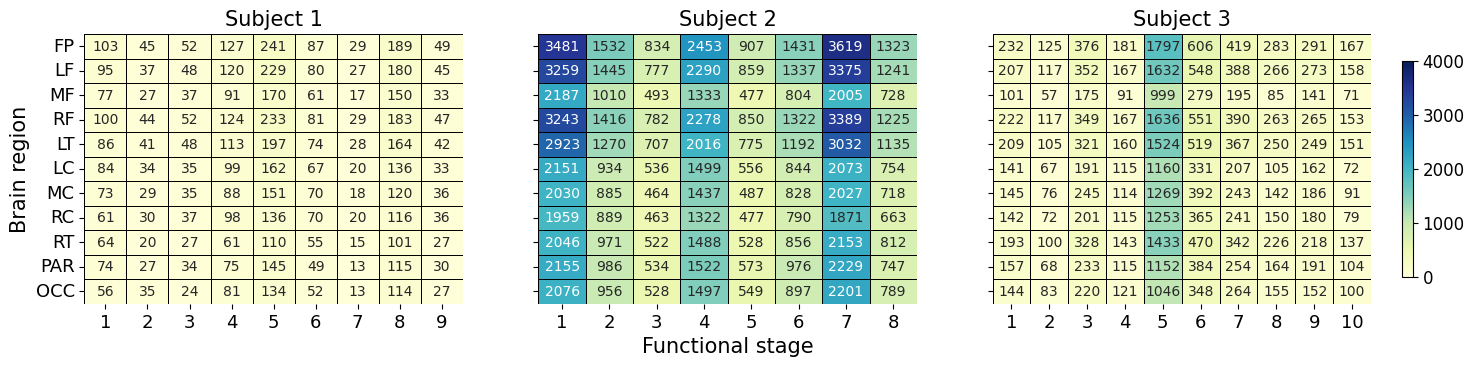

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(20, 3.5), sharey=True)

show("Subj1", axes[0], "Subject 1")
show("Subj2", axes[1], "Subject 2")
show("Subj3", axes[2], "Subject 3")

axes[0].set_ylabel("Brain region", fontsize=15)
axes[1].set_xlabel("Functional stage", fontsize=15)

norm = plt.Normalize(vmin=0, vmax=4000)
sm = plt.cm.ScalarMappable(cmap="YlGnBu", norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.tolist(), location='right', shrink=0.8, pad=0.02)
cbar.ax.tick_params(labelsize=12)

# fig.tight_layout()

fig.savefig("dim_5_analysis.svg")
fig.savefig("dim_5_analysis.eps")